# LEARNING OBJECTIVE

This notebook shows how to visualize the unsteady solution to Stokes' 2nd problem of the post-transient ("steady") oscillations of a plate/wall.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [2]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# ploting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np
from scipy.optimize import fsolve

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# STOKES' 2<sup>nd</sup> PROBLEM

The problem of the post-transient ("steady") unidirectional flow caused by an oscillating plate was first considered by [G. G. Stokes](https://en.wikipedia.org/wiki/Sir_George_Stokes,_1st_Baronet) in his 1850 treatise "On the effect of the internal friction of fluids on the motion of pendulums" published in the [_Transactions of the Cambridge Philosophical Society_](https://archive.org/details/b22464074/page/92/mode/2up) (pages 13-14, "art. 7").

For some _very thorny_ issues related to Stokes' 2nd problem for certain viscoelastic (non-Newtonian) fluids, see [my article](https://arxiv.org/abs/1111.4464).

The post-transient solution that we derived in class (see also Section 11.4 of Panton) is
$$
    \frac{v_x}{V_0} (y,t) = e^{-\frac{y}{\sqrt{2\nu/\Omega}}} \sin\left(\Omega t - \frac{y}{\sqrt{2\nu/\Omega}} \right).
$$

We can now let ${v}_x^* = v_x/V_0$, $y^* = y/\sqrt{2\nu/\Omega}$, and $t^* = \Omega t$ be the dimensionless velocity, the dimensionless distance from the plate, and the dimensionless time, respectively. Then, the profile is
$$ 
    v_x^*(y^*,t^*) = e^{-y^*} \sin\left(t^* - y^*\right).
$$

This form of the solution has no free parameters, it is _universal_. However, it is unsteady, so we wish to see it at different instants of $t^*$ by making an animation. 

Keep in mind that $t^*=0$ is just some arbirtrary timepoint, at which we've reset time, once the flow is the post-transient, periodic regime. That is, transients due to startup from rest took place for $t^*<0$.

In [11]:
# define vertical extent of plot and grid
ymax = 6.0
y = np.linspace(0, ymax, endpoint=True)

# set up the figure and axis
fig, ax = plt.subplots()
ax.set_ylabel('$y^*$')
ax.set_ylim(0,ymax)
ax.set_xlabel('$v_x^*$')
ax.set_xlim(-1,1)
# if you want to move horizontal axis label to top so it doesn't clash with animation controls
# but plt.tight_layout() also fixes this
#ax.xaxis.set_label_position('top')
#ax.xaxis.set_ticks_position('top')
plt.tight_layout()
plt.close()

# initialize plot and quiver objects with some dummy data (replaced in animation)
line, = ax.plot(0*y, y, color='blue', linewidth=4, label='$t=0$')
# add envelope of all curves
ax.plot(np.exp(-y), y, color='gray', linewidth=1, linestyle='dashed', label='envelope, $e^{-y^*}$')
ax.plot(-np.exp(-y), y, color='gray', linewidth=1, linestyle='dashed')
# skip every other data point to reduce number of arrows
quiv = ax.quiver(0*y[::2], y[::2], 0*y[::2], 0*y[::2],
                 scale=1., scale_units='xy', color='skyblue', zorder=2)
legend = ax.legend()

# number of animation frames
numframes = 100
tmax = 100

# animation function called sequentially by `FuncAnimation' below
def animate(t):
    # the t passed is actually the frame counter, not time
    # so it should be rescaled to get actual time as % of the frames
    # also shift it slightly so we don't divide by 0
    tt = 0.0 + t/numframes * tmax

    vx = np.exp(-y)*np.sin(tt-y)
    line.set_data(vx, y)
    # updating the legend in an animation gets weird
    legend.get_texts()[0].set_text(f'$t^* = {tt:.2f}$')
    # plot arrows emanating only from the reference line, x-coord = 0
    quiv.set_UVC(vx[::2], 0*vx[::2])

    return (line,quiv,)

anim = animation.FuncAnimation(fig, animate,
                               frames=numframes,
                               interval=500,
                               blit=True)

# this is necessary to get the animation to work on Google's Colab
rc('animation', html='jshtml')
anim

## Discussion: the viscous oscillatory "boundary layer" thickness

From this interactive plot, we observe that the velocity variation is confined to a "oscillatory boundary layer" near the plate, decaying quickly away from the plate.

Let us calculate this "boundary layer thickness" by solving for the value of $y^*$ such that $v_x^*=0.01$ (equivalently, $y$ such that $v_x = 0.01V_0$, in dimensional form). The value $y^*$ represents the distance above the plate at which the velocity has decayed to a mere 1% of the plate's velocity.

However, $v_x^*$ is unsteady and depends on both $y^*$ and $t^*$. For definiteness, let us just pose the question for the _envelope_ of $v_x^*$. Since $-1 \le \sin(y^* - t^*)\le 1$, the enevolpe of $v_x^*$ is $e^{-y^*}$, which is the quantity that sets the amplitude of the velocity oscillations.

This can be done, in general, using [SciPy](https://docs.scipy.org/doc/scipy/reference/optimize.html#root-finding)'s nonlinear root-finding capabilities.

In [ ]:
def eq_func(ystar):
    # define a function v_envelope(y*) - 0.01, which = 0 for the value
    # of y* = delta* that we seek as a solution; although for this function
    # you could've done this by hand, let's use scipy anyways ...
    return np.exp(-ystar) - 0.01

ystar_initial_guess = 1
ystar_sol = fsolve(eq_func, ystar_initial_guess)
ystar_sol[0]

In [5]:
ystar_sol[0]*np.sqrt(2)

Therefore, the "boundary layer thickness" is $y^* = \delta^* \approx 4.6$, or
$$ 
    y = \delta \approx 4.6 \sqrt{\frac{2\nu}{\Omega}} \approx 6.5 \sqrt{\frac{\nu}{\Omega}}
$$
in dimensional form.

Similar to Stokes' 1<sup>st</sup> problem, this distance is proportional to $\sqrt{\nu}$. Unlike Stokes' 1<sup>st</sup> problem, this distance is independent of $t$. Also unlike Stokes' 1<sup>st</sup> problem, the plate's oscillation frequency $\Omega$ reduces the oscillatory boundary layer thickness. For fast plate motion, the fluid doesn't have time to "react" to the oscillations.

We can show this thickness on the velocity field plot:

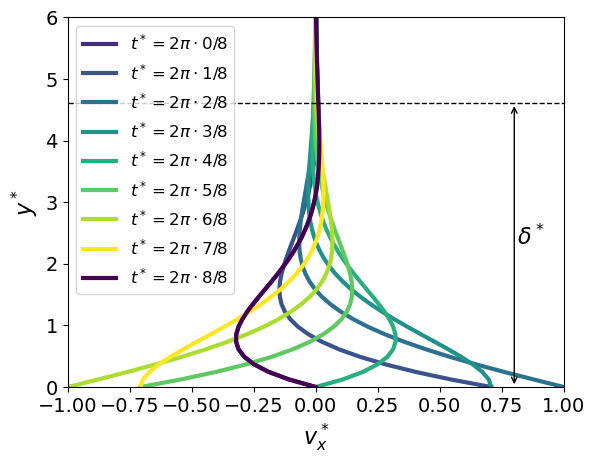

In [6]:
# define vertical extent of plot and grid
ymax = 6.0
y = np.linspace(0, ymax, endpoint=True)

# sequential colormap with gradient that looks nice, also try 'cool' or 'summer'
# https://matplotlib.org/stable/users/explain/colors/colormaps.html#sequential
cmap = colormaps['viridis']

# set up the figure and axis
fig, ax = plt.subplots()
ax.set_ylabel('$y^*$')
ax.set_ylim(0,ymax)
ax.set_xlabel('$v_x^*$')
ax.set_xlim(-1,1)

ts = np.linspace(0,2*np.pi,9,endpoint=True)
for i in range(0,len(ts)):
  vx = np.exp(-y)*np.sin(ts[i]-y)
  randcol = cmap(ts[(i+1)%9]/ts.max()) # argument from 0 to 1
  ax.plot(vx, y, linewidth=3, color=randcol, label=rf'$t^* = 2\pi\cdot{i}/8$')

ax.legend(loc='upper left')

ax.plot(np.linspace(-1,1), ystar_sol[0]*np.ones_like(np.linspace(-1,1)),
        linewidth=1, color='black', linestyle='dashed')
# add nice arrow
ax.text(0.81, ystar_sol[0]/2, r'$\delta^*$', fontdict={'size': 16});
ax.annotate("", (0.8, 0), (0.8, ystar_sol[0]), arrowprops={'arrowstyle':'<->'});

## Final remark

In the animation above, there is also a clear _phase lag_ between the velocity (and direction) of fluid some distance above the plate and the velocity of/ near/ at the plate. It almost looks like "wave" is "propagating" up from the plate. It is not a true wave but it looks like one. We call it a [_kinematic wave_](https://www.linkedin.com/pulse/kinematic-waves-ivan-christov). Can you figure out its phase speed from the exact solution? (See also Panton, bottom of p. 230.)